# 데이터 증강 프로젝트
PyTorch 데이터 증강 기법(CutMix, MixUp) 실습 노트북입니다.

In [1]:
# !pip install --upgrade pip
# !pip install --upgrade torch torchvision

### 라이브러리 임포트
학습 및 연산 라이브러리를 준비합니다.

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
print("=3")

=3


In [11]:
import os
import urllib.request
import tarfile

# 저장할 경로 설정
data_dir = './data'
target_file = os.path.join(data_dir, 'images.tar')

# 1. 파일 다운로드
if not os.path.exists(target_file):
    print("Downloading images.tar...")
    url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"
    urllib.request.urlretrieve(url, target_file)
    print("Download complete.")
else:
    print("File already exists.")

# 2. 압축 해제
print("Extracting files...")
with tarfile.open(target_file, 'r') as tar:
    tar.extractall(path=data_dir)
print("Extraction complete.")


Download complete.
Extracting files...


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20032\791779508.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=data_dir)


Extraction complete.


### 데이터셋 준비
ImageNet Dogs 데이터셋을 가져옵니다.

### DataLoader 설계
이미지를 모델에 넣기 좋게 변환하고 나눕니다.

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

# 1. 데이터셋 경로 설정 및 이미지 변형(Transform) 정의
dataset_dir = "./data/Images/"  # 이미지가 저장된 로컬 경로 (현재 폴더 내 data/Images)

# 전처리 설정: 224x224 크기 조정, 텐서 변환, 그리고 평균 0.5/표준편차 0.5로 정규화
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 2. ImageFolder를 사용하여 데이터셋 로드
# 폴더 구조를 기반으로 클래스를 자동 분류하여 전체 데이터셋을 생성합니다.
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

# 3. 데이터셋 분할 (Train/Test Split)
total_size = len(full_dataset)           # 전체 데이터 개수 확인
train_size = int(0.583 * total_size)     # 전체의 약 58.3%를 학습용으로 설정
test_size = total_size - train_size      # 나머지를 테스트용으로 설정
# 설정한 크기에 맞춰 데이터셋을 무작위로 나눕니다.
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

# 4. DataLoader 생성
# 학습용 데이터는 shuffle=True를 주어 매 에폭마다 순서를 섞어줍니다.
train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
# 테스트용 데이터는 순서가 중요하지 않으므로 shuffle=False로 설정합니다.
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)

# 5. 데이터셋 정보 요약
# 클래스 개수와 클래스 이름을 딕셔너리 형태로 저장합니다.
ds_info = {
    "num_classes": len(full_dataset.classes), 
    "class_names": full_dataset.classes
}

# 결과 확인용 출력 (선택 사항)
print(f"Total: {total_size} | Train: {len(ds_train)} | Test: {len(ds_test)}")
print(f"Number of classes: {ds_info['num_classes']}")

print("=3")

=3


### 데이터 로더 검사
정상 변환되었는지 출력해봅니다.

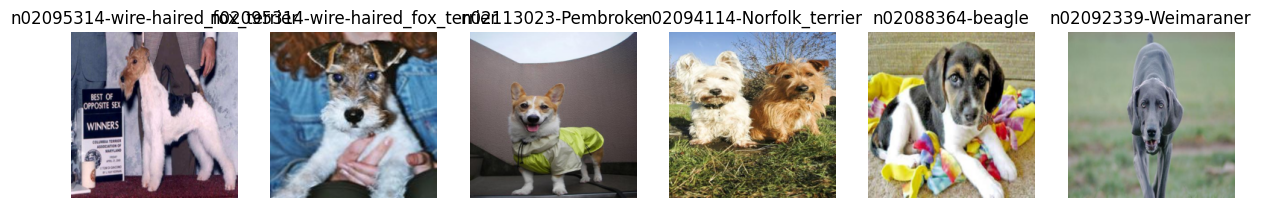

In [15]:
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()  
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])
    plt.show()

show_examples(train_loader, ds_info["class_names"])

In [16]:
def normalize_and_resize_img():
    return transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

In [17]:
def augment():
    return transforms.Compose([transforms.RandomHorizontalFlip(p=0.5), transforms.ColorJitter(brightness=0.2)])
print("=3")

=3


In [18]:
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalize_and_resize_img()
    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([*augment().transforms, *transform.transforms])
    else:
        dataset.dataset.transform = transform
    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=2, pin_memory=True)
print("=3")

=3


### 강력한 증강 기법
랜덤 회전과 영역 자르기 등 복합 증강을 선언합니다.

In [19]:
import random
def augment2():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),  # 좌우 대칭
        transforms.RandomVerticalFlip(p=0.5),    # 상하 대칭
        transforms.RandomRotation(degrees=(0, 90, 180, 270)),  # 각도 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 색상 왜곡
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 일부 영역 랜덤 크롭 후 리사이즈
        transforms.Lambda(lambda img: torch.clamp(img, 0, 1))  # 픽셀값 이탈 방지
    ])
print("=3")

=3


### Baseline 모델
순수 ResNet50 모델을 ImageNet 가중치 기반으로 로드합니다.

In [20]:
import torch.nn as nn
import torchvision.models as models
num_classes = len(ds_info["class_names"])
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes) # 마지막 분류 노드를 개 품종수로 변경
print("=3")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Hwang/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 63.8MB/s]


=3


### Augmentation 훈련용 모델
위 모델과 쌍둥이로 비교할 증강 전용 모델을 선언합니다.

In [21]:
aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)
print("=3")

=3


### DataLoader 정리
무증강훈련형, 증강훈련형, 무증강평가형 DataLoader 세 축을 정리합니다.

In [22]:
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test = apply_normalize_on_dataset(ds_test, is_test=True)
print("=3")

=3


### 무증강 모델 학습
모델을 GPU에 로드하고 오차역전파 기반 학습 루프를 돕니다.

In [ ]:
%%time
import torch.optim as optim
EPOCH = 3 # 실습 시간상 짧게 지정
criterion = nn.CrossEntropyLoss() # 다중 분류 특화 오차함수
optimizer = optim.SGD(resnet50.parameters(), lr=0.001)

def train(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy': []}
    for epoch in range(epochs):
        model.train() # 학습 모드
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels) # 오차 계산
            loss.backward() # 역전파
            optimizer.step() # 가중치 갱신
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {train_acc:.2f}%")
        
        model.eval() # 평가 모드
        correct, total = 0, 0
        with torch.no_grad(): # 역전파 차단
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")
    return history

history_resnet50_no_aug = train(resnet50, ds_train_no_aug, ds_test, EPOCH)

### 증강 모델 학습
증강 로더를 사용해 쌍둥이 모델을 마저 학습시킵니다.

In [ ]:
%%time
history_resnet50_aug = train(aug_resnet50, ds_train_aug, ds_test, EPOCH)

### 학습 곡선 시각화 비교
학습 히스토리를 꺾은선 도표로 비교합니다.

In [ ]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [ ]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True) # 격자 추가
plt.ylim(0.50, 0.80) # Y축 정밀도 범위 설정
plt.show()

### CutMix 준비
CutMix를 위해 데이터 로더에서 서로 다른 2개의 이미지 텐서를 확인합니다.

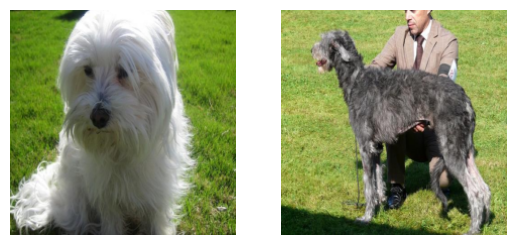

In [23]:
import matplotlib.pyplot as plt
data_iter = iter(ds_train_no_aug)
images, labels = next(data_iter)

# 원본 A 강아지와 B 강아지 데이터 지정 및 넘파이 변환
image_a = images[0].permute(1, 2, 0).numpy()
image_b = images[1].permute(1, 2, 0).numpy()
label_a = labels[0].item()
label_b = labels[1].item()

# 디노멀라이즈 원본 복구
image_a = (image_a * 0.5) + 0.5
image_b = (image_b * 0.5) + 0.5

# 2x1 레이아웃으로 도식화
plt.subplot(1, 2, 1)
plt.imshow(image_a)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_b)
plt.axis('off')

plt.show()

### CutMix 바운딩 박스 생성
이미지에서 오려낼 난수 크기의 사각형 영역을 도출합니다.

In [30]:
def get_clip_box(image_a, image_b):
    image_size_x = image_a.shape[2]  # 너비
    image_size_y = image_a.shape[1]  # 높이

    # 자를 박스의 추정 중심점 랜덤 생성
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    # 면적 및 x축, y축 무작위 한계 넓이 계산
    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    # 실제 박스 경계선 점 (x좌표 최좌단 우단, y좌표 최상단 하단 클리핑)
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)
print('x :', x_min, x_max)
print('y :', y_min, y_max)

x : 1 3
y : 77 224


### CutMix 이미지 패치 연산
A 이미지 위에 앞서 만든 B 박스를 오려와 덧붙입니다.

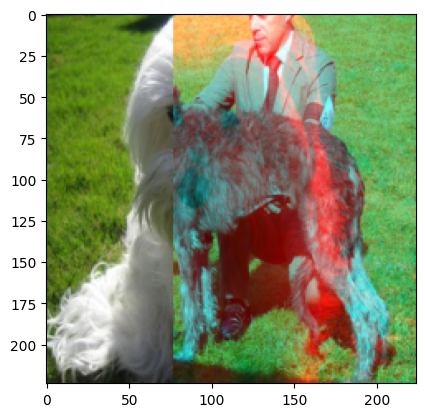

In [31]:
import torch
def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    image_size_x = image_a.shape[2]
    image_size_y = image_a.shape[1]

    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a).to(device)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b).to(device)

    top = image_a[:, :y_min, :]          # 상단부 절단
    middle_left = image_a[:, y_min:y_max, :x_min] # 중단부 왼쪽 A
    middle_center = image_b[:, y_min:y_max, x_min:x_max] # 중심부 타겟 B 영역
    middle_right = image_a[:, y_min:y_max, x_max:] # 중단부 오른쪽 A
    bottom = image_a[:, y_max:, :]       # 하단부 잔여석

    top, middle_left, middle_center, middle_right, bottom = top.to(device), middle_left.to(device), middle_center.to(device), middle_right.to(device), bottom.to(device)

    # 가로축 행렬 접합 (중단부 병합)
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)
    # 세로축 최종 이미지 병합
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img

mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)
plt.imshow(mixed_img.cpu().numpy())
plt.show()

### CutMix 정답(Label) 하이브리드
오려붙인 면적 비율에 맞춰 클래스 정답 퍼센트를 분할시킵니다.

In [33]:
import torch.nn.functional as F
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120):
    image_size_x = image_a.shape[2] 
    image_size_y = image_a.shape[1] 

    # 교체된 바운딩 박스의 총 면적 비율에 라벨 확률도 비례합니다
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float() # One-Hot 벡터로 변환
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 면적 비율 만큼 라벨 A와 라벨 B 확률을 분리 통합합니다.
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label

mixed_label = mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max)
print(mixed_label)

tensor([0.0000, 0.0000, 0.5625, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4375,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

### 전체 배치 CutMix화
미니배치의 모든 샘플에 대하여 일괄 CutMix화 하는 패키징입니다.

In [34]:
def cutmix(images, labels, prob=1.0, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()  # 덮어씌울 랜덤 타겟 인덱스 도출
        image_b = images[j]
        label_b = labels[j]

        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b) # 바운딩 박스
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)) # 이미지 믹스
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes)) # 라벨 분포 믹스

    # 배열을 실제 네트워크 인입용 텐서 스택 구조로 재포장함
    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels

print("=3")

=3


### MixUp: 알파 블렌딩
CutMix와는 달리 두 이미지를 박스로 오리지 않고 투명도를 기반으로 섞어버리는 MixUp 기법입니다.

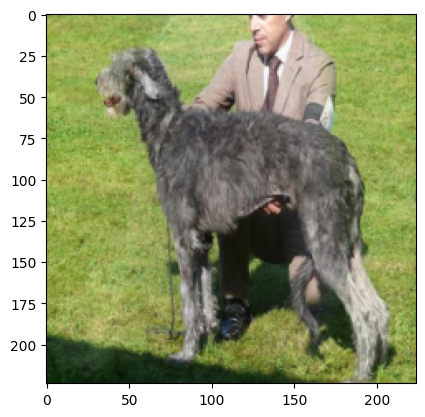

tensor([0.0000, 0.0000, 0.1312, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8688,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [44]:
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()  # 불투명도를 결정할 랜덤 비율

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_image = (1 - ratio) * image_a + ratio * image_b # 이미지 알파 농도 조절 병합
    mixed_label = (1 - ratio) * label_a + ratio * label_b # 정답 결과 알파 농도 병합

    return mixed_image, mixed_label

mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b)
plt.imshow(mixed_img)
plt.show()
print(mixed_label)

### MixUp 일괄 배치 래퍼 모듈
전체 훈련 단위로 MixUp 로직을 실행하는 총괄 함수입니다.

In [36]:
def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a, label_a = images[i], labels[i]

        j = torch.randint(0, batch_size, (1,)).item()
        image_b, label_b = images[j], labels[j]

        # 믹스업 블렌딩 처리
        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 4차원 스택화
    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)  # (B, C, H, W)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)  # (B, num_classes)

    return mixed_imgs, mixed_labels

print('=3')

=3
